In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [2]:
# 小盘：2.5-20 亿$
# 中盘：20-100 亿$
# 蓝筹：>100 亿$
# ---------------------------
# 1) 股票分组
# ---------------------------
AI_max = ["MSFT", "GOOGL", "META", "AMZN", "TSLA", "ORCL", "CRM", "ADBE"]
AI_mid = ["SNOW", "PLTR", "DDOG", "MDB", "U", "CRWD", "ZS", "NET"]
AI_min = ["AI", "BBAI", "SOUN", "VERI", "UPST", "CXAI"]

finance_max = ["JPM", "BAC", "WFC", "C", "GS", "MS", "AXP", "BLK", "SCHW"]
finance_mid = ["USB", "PNC", "TFC", "COF", "STT", "BK", "MTB", "FITB", "CFG"]
finance_min = ["HOOD", "SOFI", "AFRM", "LC", "MQ", "NU", "HIPO", "ROOT"]

encryption_max = ["COIN", "MSTR", "MARA", "RIOT", "CLSK", "HUT", "HIVE", "BITF"]
encryption_mid = ["CIFR", "WULF", "IREN", "BTBT", "CORZ", "BKKT", "BTDR"]
encryption_min = ["ANY", "ARBK", "ABTC", "GREE", "BTCS"]

semiconductor_max = ["NVDA", "AMD", "INTC", "AVGO", "QCOM", "TXN", "ADI", "MU", "NXPI", "TSM"]
semiconductor_mid = ["MCHP", "MPWR", "ON", "LRCX", "KLAC", "TER", "GFS"]
semiconductor_min = ["AEHR", "NVTS", "INDI", "LASR", "HIMX", "SMTC", "AMBA", "POWI"]

In [3]:
proxy = 'http://127.0.0.1:7890'  # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [ ]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"):
    os.environ.pop(v, None)

# 按照行业、盘子大小获取数据(每日)

In [4]:
# 展平去重
tickers = sorted(set(
    AI_max + AI_mid + AI_min +
    finance_max + finance_mid + finance_min +
    encryption_max + encryption_mid + encryption_min +
    semiconductor_max + semiconductor_mid + semiconductor_min
))

start_date = "2025-11-15"
end_date_exclusive = "2025-12-01"  # end 右开：包含到 11/30（若有交易日）

data2 = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date_exclusive,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 先提取日收盘价（优先 Close；没有就用 Adj Close）
if isinstance(data2.columns, pd.MultiIndex):
    if "Close" in data2.columns.get_level_values(1):
        px_daily = data2.xs("Close", axis=1, level=1)
    else:
        px_daily = data2.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data2.columns else "Adj Close"
    px_daily = data2[[col]].rename(columns={col: tickers[0]})

# 再保险截一下范围（只保留 11/15~11/30）
px_daily = px_daily.loc["2025-11-15":"2025-11-30"]

# 计算“日收益率 / 日涨跌幅”（简单收益率）
df_stock_daily = px_daily.pct_change()


# 按照行业获取ETF涨跌幅数据（每日）

In [5]:
# ---------------------------
AI_ETF = ["QQQ", "AIQ", "BOTZ"]
FIN_ETF = ["XLF", "KRE", "PSCF"]
CRYP_ETF = ["IBIT", "BLOK", "WGMI"]
SEMI_ETF = ["SMH", "SOXX", "XSD"]

etfs = sorted(set(AI_ETF + FIN_ETF + CRYP_ETF + SEMI_ETF))

In [6]:
# ---------------------------
# 2. 时间区间（end 右开：要包含 2025-12-01，就写到 2025-12-02）
# ---------------------------
start_date = "2025-11-15"
end_date   = "2025-12-02"

# ---------------------------
# 3. 下载日线数据
# ---------------------------
data = yf.download(
    tickers=" ".join(etfs),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# ---------------------------
# 4. 提取日价格（Close；若没有 Close 就退回 Adj Close）
# ---------------------------
if isinstance(data.columns, pd.MultiIndex):
    if "Close" in data.columns.get_level_values(1):
        px_daily = data.xs("Close", axis=1, level=1)
    else:
        px_daily = data.xs("Adj Close", axis=1, level=1)
else:
    col = "Close" if "Close" in data.columns else "Adj Close"
    px_daily = data[[col]].rename(columns={col: etfs[0]})

# ---------------------------
# 5. 截取区间：2025-11-15 ~ 2025-12-01（两端都包含）
# ---------------------------
px_daily = px_daily.loc["2025-11-15":"2025-12-01"]

# ---------------------------
# 6. 计算“日收益率 / 日涨跌幅”
# ---------------------------
df_etf_daily = px_daily.pct_change()
# 如果不想要第一行 NaN，可取消注释：
# df_etf_daily = df_etf_daily.dropna(how="all")


1 Failed download:
['SOXX']: SSLError('Failed to perform, curl: (35) TLS connect error: error:00000000:invalid library (0):OPENSSL_internal:invalid library (0). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_28600\1288726723.py:41: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_etf_daily = px_daily.pct_change()


# 以日为单位，对每支股票涨跌幅可视化

In [7]:
# 个股分组
groups = {
    "AI": {
        "max": AI_max,
        "mid": AI_mid,
        "min": AI_min,
        "etf": ["QQQ", "AIQ", "BOTZ"]
    },
    "Finance": {
        "max": finance_max,
        "mid": finance_mid,
        "min": finance_min,
        "etf": ["XLF", "KRE", "PSCF"]
    },
    "Crypto": {
        "max": encryption_max,
        "mid": encryption_mid,
        "min": encryption_min,
        "etf": ["IBIT", "BLOK", "WGMI"]
    },
    "Semiconductor": {
        "max": semiconductor_max,
        "mid": semiconductor_mid,
        "min": semiconductor_min,
        "etf": ["SMH", "SOXX", "XSD"]
    }
}

C:\Users\Administrator\AppData\Local\Temp\ipykernel_28600\2589974321.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


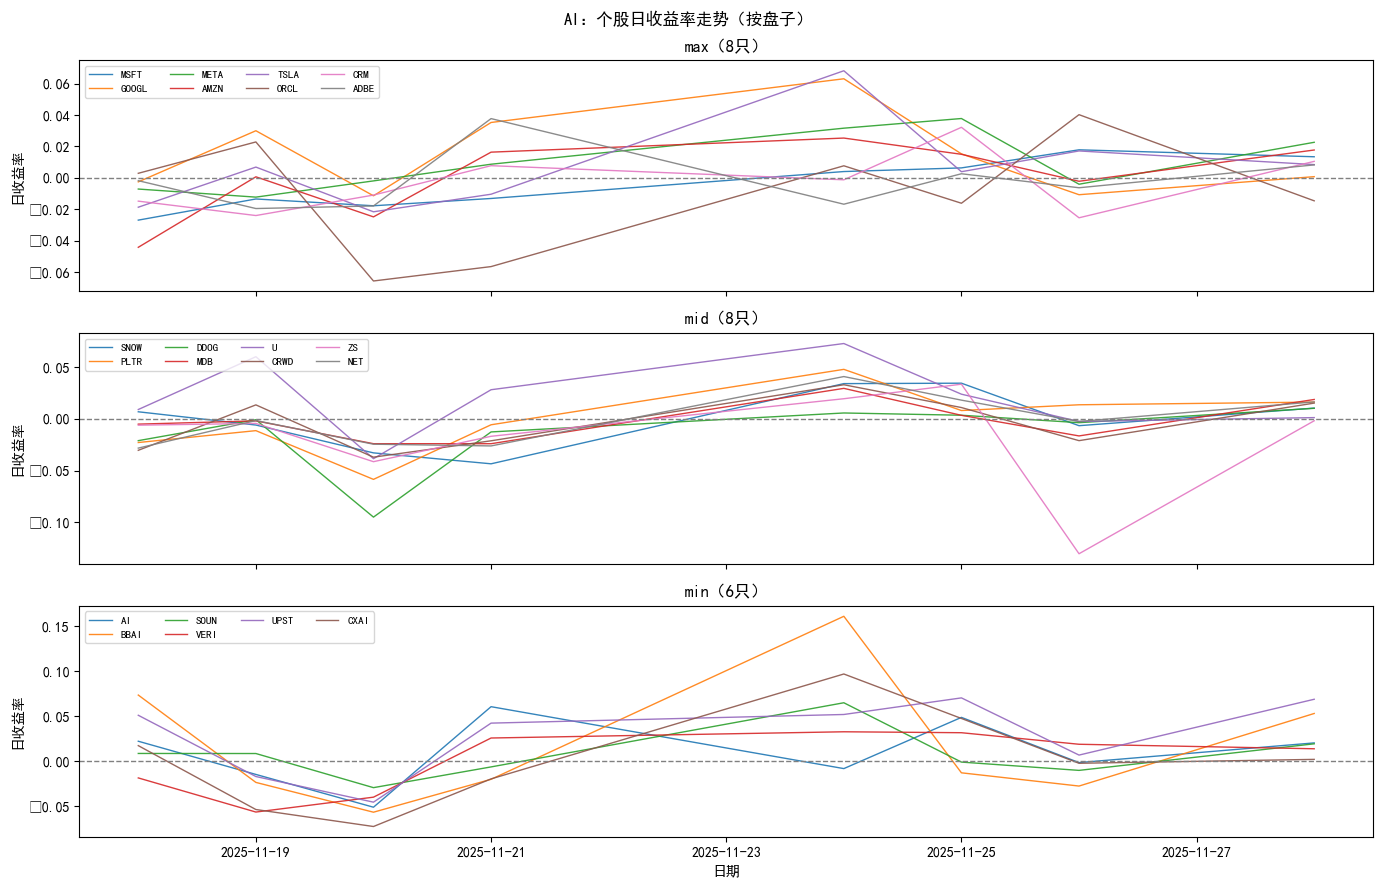

C:\Users\Administrator\AppData\Local\Temp\ipykernel_28600\2589974321.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


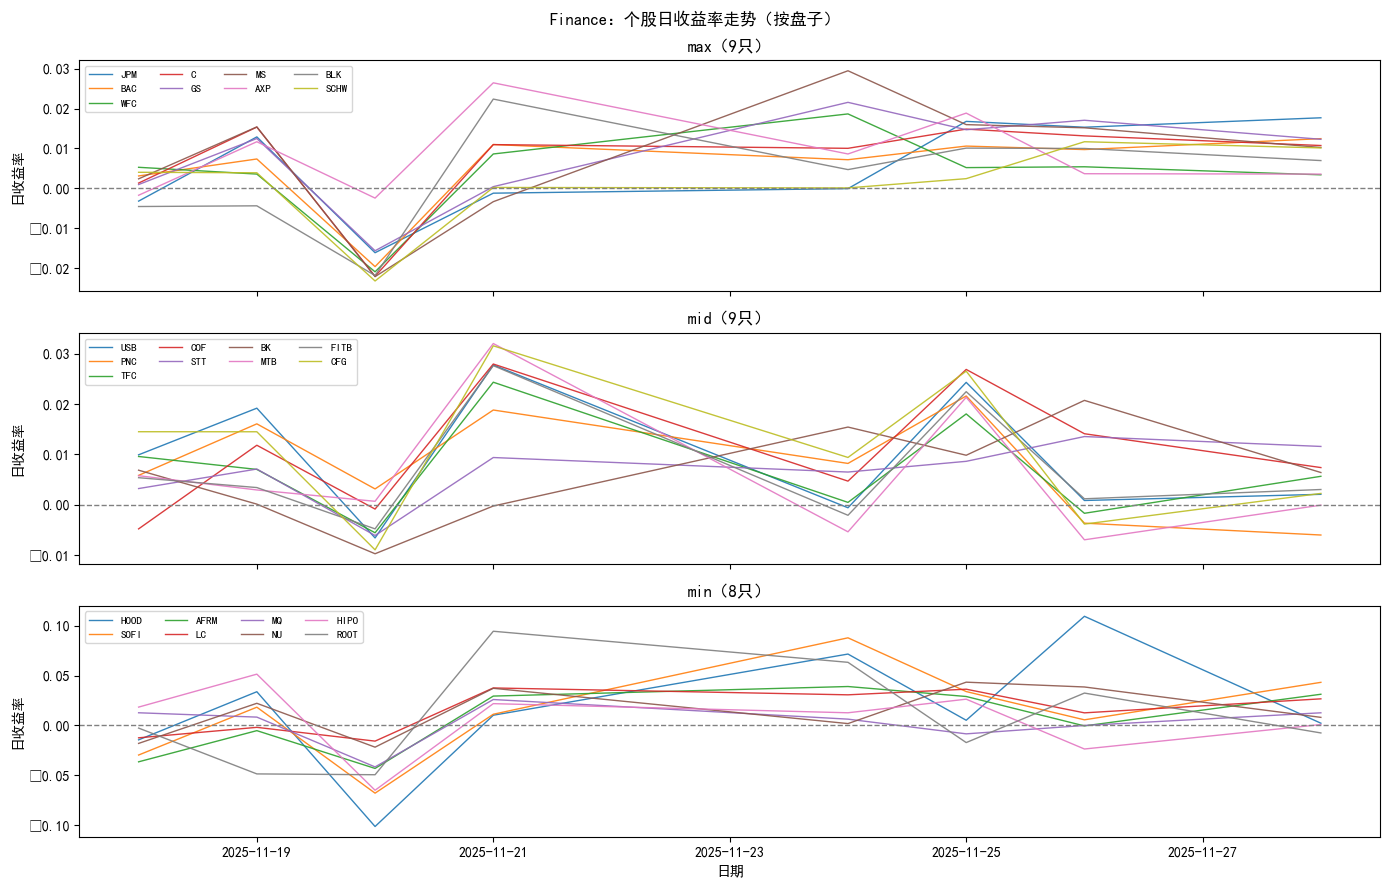

C:\Users\Administrator\AppData\Local\Temp\ipykernel_28600\2589974321.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


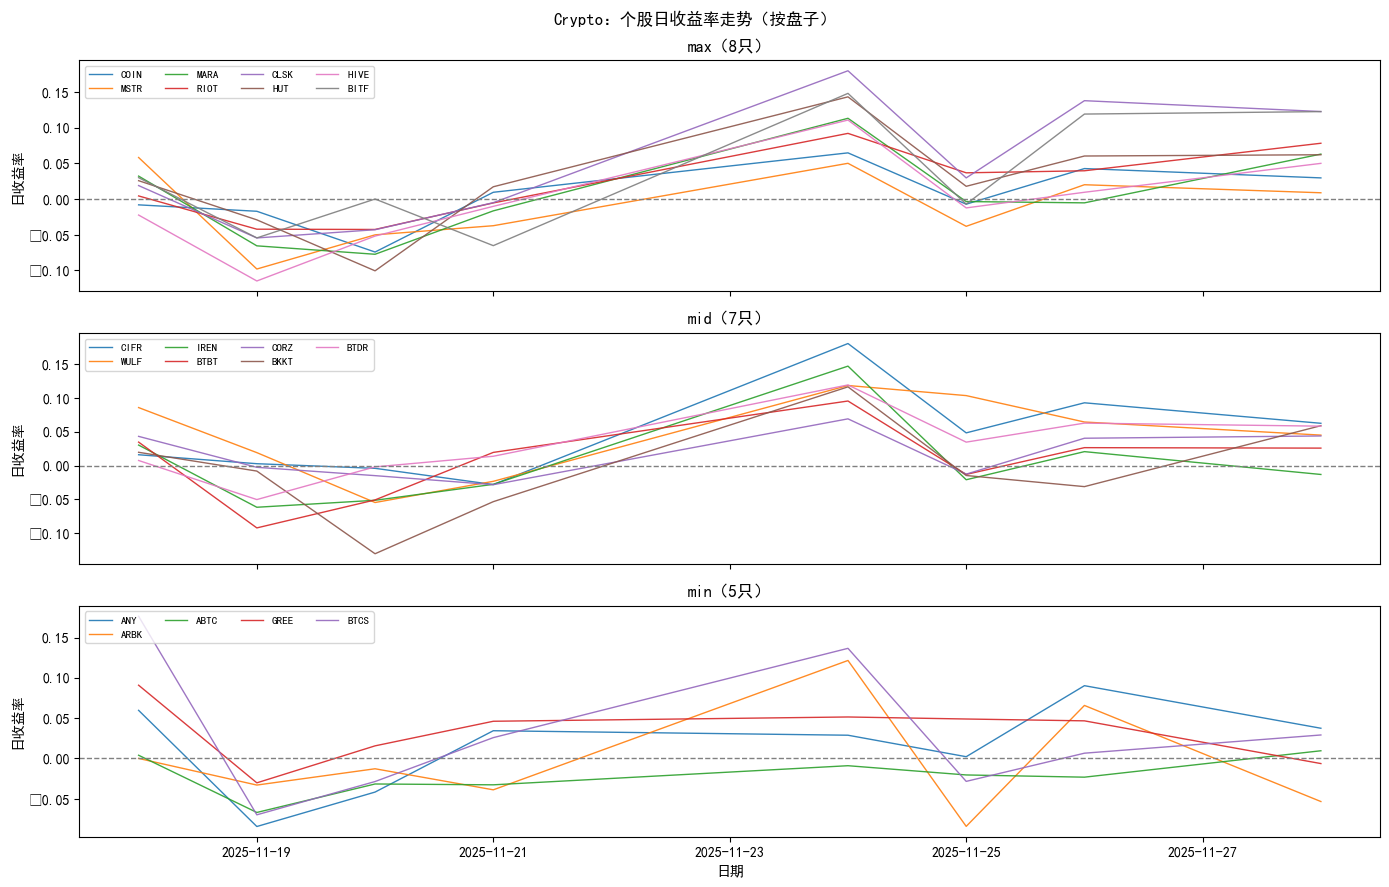

C:\Users\Administrator\AppData\Local\Temp\ipykernel_28600\2589974321.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


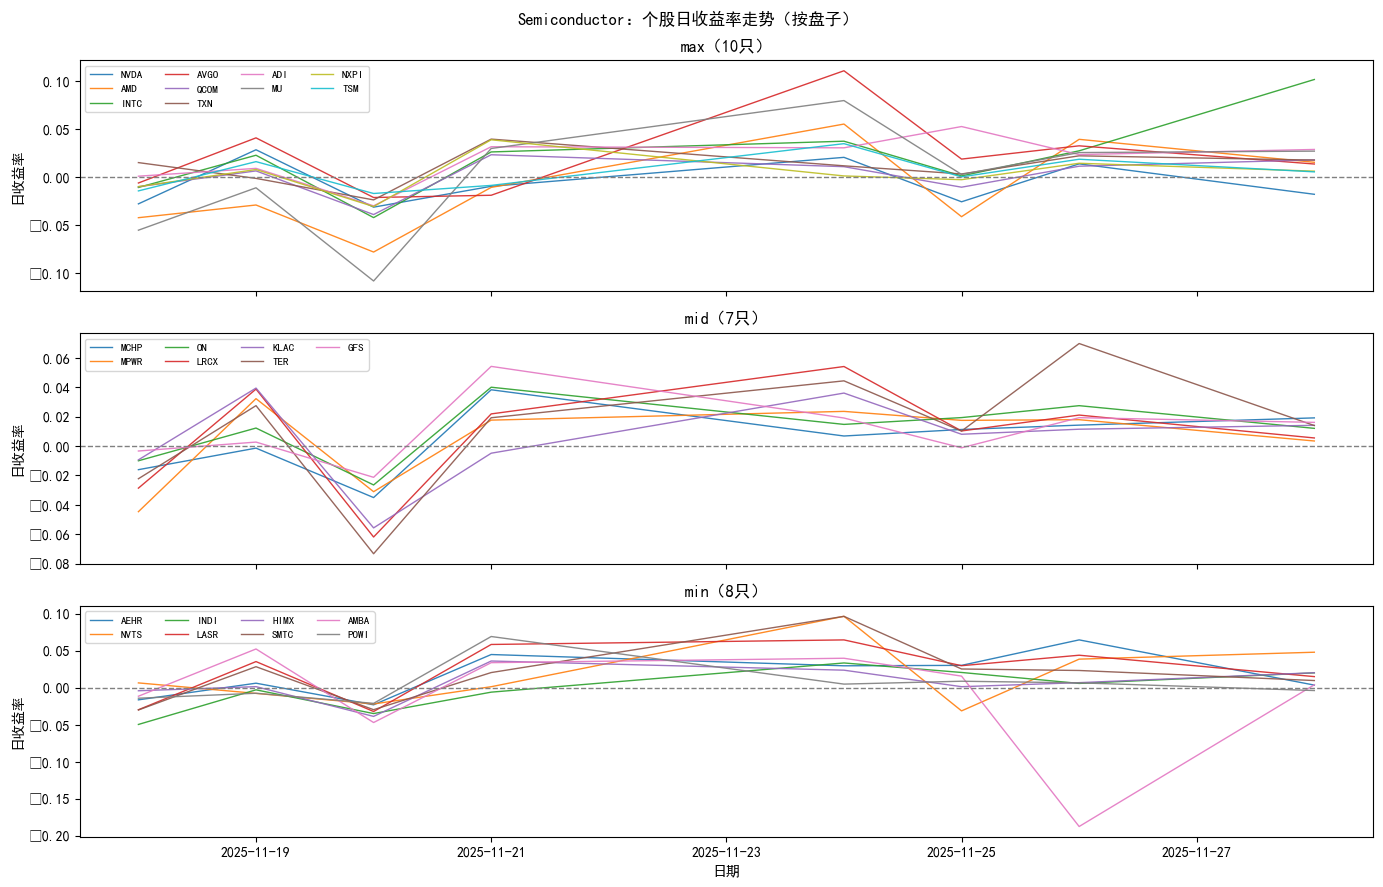

In [8]:
df = df_stock_daily.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# =========================
# 按行业 + 盘子：画每支股票“日收益率走势”
# 每个行业一张图，3 个子图分别是 max / mid / min
# =========================
for sector, cfg in groups.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{sector}：个股日收益率走势（按盘子）", y=0.98)

    for ax, size, stock_list in zip(
        axes,
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [s for s in stock_list if s in df.columns]
        if len(stock_cols) == 0:
            ax.text(0.5, 0.5, f"{size}: 无股票数据", transform=ax.transAxes,
                    ha="center", va="center")
            ax.set_axis_off()
            continue

        sub = df[stock_cols].dropna(how="all")

        # 线很多时不画 legend（避免太乱）；线少时画 legend
        if len(stock_cols) <= 20:
            for t in stock_cols:
                ax.plot(sub.index, sub[t], linewidth=1, alpha=0.9, label=t)
            ax.legend(fontsize=8, ncol=4, loc="upper left")
        else:
            ax.plot(sub.index, sub.values, linewidth=0.8, alpha=0.7)
            ax.text(0.99, 0.01, f"{len(stock_cols)} stocks (legend omitted)",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=9)

        ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
        ax.set_title(f"{size}（{len(stock_cols)}只）")
        ax.set_ylabel("日收益率")

    axes[-1].set_xlabel("日期")
    plt.tight_layout()
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的CNN来提取液滴图像特征
class CellClassifier(nn.Module):
    def __init__(self):
        super(CellClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 1),
            nn.Sigmoid() # 输出 0-1 之间的概率，代表阳性的可能性
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# 假设你已经训练好了这个模型
perception_model = CellClassifier()
perception_model.eval()

import gymnasium as gym
from gymnasium import spaces
import numpy as np

class MicrofluidicEnv(gym.Env):
    def __init__(self, cnn_model):
        super(MicrofluidicEnv, self).__init__()
        self.cnn_model = cnn_model
        
        # 动作空间：0 (丢弃), 1 (分选)
        self.action_space = spaces.Discrete(2)
        
        # 状态空间：[CNN预测概率, 分选针头是否就绪, 液滴流速]
        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)
        
    def step(self, action):
        # 1. 模拟物理世界中的液滴真值 (仅用于计算奖励)
        is_positive = np.random.choice([0, 1], p=[0.9, 0.1]) # 假设10%是真阳性
        
        # 2. 获取当前状态 (假设 CNN 给出的预测分值)
        # 在真实系统中，这里会传入实时图像给 cnn_model
        prediction_score = 0.95 if is_positive else 0.05 
        
        reward = 0
        if action == 1: # 选择分选
            if is_positive:
                reward = 10  # 成功富集阳性细胞，大奖！
            else:
                reward = -5  # 误选阴性，纯度下降，惩罚
        else: # 选择丢弃
            if is_positive:
                reward = -10 # 漏掉了阳性细胞，大惩罚
            else:
                reward = 1   # 正确排除垃圾，小奖
        
        # 更新状态（简化处理）
        next_state = np.array([prediction_score, 1.0, 0.5], dtype=np.float32)
        done = False # 这里可以根据实验时长决定是否结束
        
        return next_state, reward, done, False, {}

    def reset(self, seed=None):
        return np.array([0.0, 1.0, 0.5], dtype=np.float32), {}
    
    
# 初始化环境
env = MicrofluidicEnv(perception_model)

# 在实际项目中，你会使用像 Stable Baselines3 这样的库来训练 RL
# 这里仅展示预测和动作的逻辑
state, _ = env.reset()

for _ in range(10):
    # 模拟 RL 代理根据状态决定 Action
    # 实际上这里会由一个训练好的 RL 模型 (如 PPO/DQN) 输出
    prob_from_cnn = state[0]
    
    if prob_from_cnn > 0.8: # 如果感知层说概率很高
        action = 1 # RL 倾向于下达分选指令
    else:
        action = 0
        
    next_state, reward, done, _, _ = env.step(action)
    print(f"感知概率: {prob_from_cnn:.2f} | 动作: {'分选' if action==1 else '丢弃'} | 获得奖励: {reward}")
    state = next_state